<a href="https://colab.research.google.com/github/vyron-arvanitis/pytorch_tutorials/blob/main/02_pytorch_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Make classification dat aand get it ready

In [1]:
import sklearn
sklearn.__version__

'1.6.1'

In [2]:
from sklearn.datasets import make_circles

# Make 1000 samples
n_samples = 1000

# Create circles
X, y = make_circles(n_samples,
                    noise=0.05,
                    random_state=42)

In [3]:
len(X), len(y)

(1000, 1000)

In [4]:
print(f"First 5 samples of X:\n {X[:5]}")
print(f"First 5 samples of y:\n {y[:5]}")

First 5 samples of X:
 [[ 0.74220688  0.24668576]
 [-0.7340323   0.16869164]
 [-0.82985872  0.22195899]
 [-0.42913559  0.67223019]
 [ 0.44560223 -0.89493556]]
First 5 samples of y:
 [1 1 1 1 0]


In [5]:
# Number of features
X.shape[1]

2

In [6]:
# MAke DataFrame of circles
import pandas as pd
circles = pd.DataFrame({"X1": X[:,0],
                        "X2": X[:, 1],
                        "label": y
                        }
                       )
circles.head(10)

,X1,X2,label
0,0.742207,0.246686,1
1,-0.734032,0.168692,1
2,-0.829859,0.221959,1
3,-0.429136,0.672230,1
4,0.445602,-0.894936,0
5,-0.469885,0.708037,1
6,-0.016045,0.805623,1
7,0.759623,0.159526,1
8,-0.175692,-0.799837,1
9,-0.110616,1.042207,0


In [7]:
circles.label.value_counts()

,count
label,
1,500
0,500


In [8]:
circles.X1

,X1
0,0.742207
1,-0.734032
2,-0.829859
3,-0.429136
4,0.445602
...,...
995,0.249091
996,-0.985370
997,-0.128231
998,0.660905


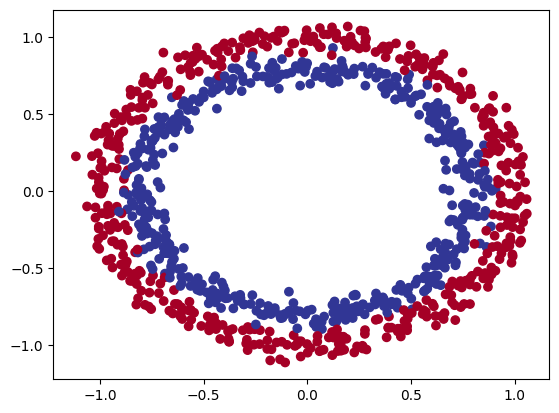

In [9]:
# Visualize the data!
import matplotlib.pyplot as plt
plt.scatter(x=circles["X1"],
            y=circles["X2"],
            c=circles["label"],
            cmap=plt.cm.RdYlBu)

### Check input and output shapes

In [10]:
X.shape, y.shape

((1000, 2), (1000,))

In [11]:
X_sample = X[0]
y_sample = y[0]
print(f"Values for one sample of X: {X_sample} and the same for y:{y_sample}")
print(f"Shapes for one sample of X: {X_sample.shape} and the same for y:{y_sample.shape}")

Values for one sample of X: [0.74220688 0.24668576] and the same for y:1
Shapes for one sample of X: (2,) and the same for y:()


### Turn data into tensors and train_test_splits

In [12]:
import torch

In [13]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [14]:
X

tensor([[ 0.7422,  0.2467],
        [-0.7340,  0.1687],
        [-0.8299,  0.2220],
        ...,
        [-0.1282, -0.8261],
        [ 0.6609, -0.7932],
        [ 0.2784,  0.9674]])

In [15]:
X.dtype, y.dtype

(torch.float32, torch.float32)

In [16]:
# Split data into train and test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    shuffle=True)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

(torch.Size([800, 2]),
 torch.Size([200, 2]),
 torch.Size([800]),
 torch.Size([200]))

## Build a model

In [17]:
import torch
from torch import nn
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [18]:
# Construc a model
class CircleModelV1(nn.Module):
  def __init__(self, in_feature: int):
    super().__init__()

    layers = []
    layers.append(nn.Linear(in_features=in_feature, out_features=5))
    layers.append(nn.Linear(in_features=5, out_features=1))
    self.sequential= nn.Sequential(*layers)

  def forward(self, x: torch.Tensor):
    return self.sequential(x)

model_0 = CircleModelV1(in_feature=X_train.shape[1]).to(device)
model_0

CircleModelV1(
  (sequential): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): Linear(in_features=5, out_features=1, bias=True)
  )
)

In [19]:
next(model_0.parameters()).device

device(type='cuda', index=0)

In [20]:
model_0.state_dict()

OrderedDict([('sequential.0.weight',
              tensor([[-0.6880,  0.5945],
                      [-0.5277,  0.3590],
                      [-0.4952, -0.2038],
                      [-0.1886, -0.4295],
                      [ 0.3069, -0.5058]], device='cuda:0')),
             ('sequential.0.bias',
              tensor([ 0.5299,  0.6430,  0.2922, -0.5622, -0.3438], device='cuda:0')),
             ('sequential.1.weight',
              tensor([[ 0.1999,  0.2935,  0.1854, -0.2246,  0.1103]], device='cuda:0')),
             ('sequential.1.bias', tensor([-0.4184], device='cuda:0'))])

In [21]:
model_0.state_dict()["sequential.0.weight"], model_0.state_dict().keys()

(tensor([[-0.6880,  0.5945],
         [-0.5277,  0.3590],
         [-0.4952, -0.2038],
         [-0.1886, -0.4295],
         [ 0.3069, -0.5058]], device='cuda:0'),
 odict_keys(['sequential.0.weight', 'sequential.0.bias', 'sequential.1.weight', 'sequential.1.bias']))

In [22]:
# Make untrained predictions
with torch.inference_mode():
  untrained_preds = model_0(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}")
print(f"Shape of predictions: {untrained_preds.shape}")
print(f"Length of test samples {len(X_test)}, Shape: {X_test.shape}")
print(f"First 10 predictions:\n {untrained_preds[:10]}")
print(f"Frist 10 predictions rounded:\n {torch.round(untrained_preds[:10])}")
print(f"First 10 labels :\n {y_test[:10]}")

Length of predictions: 200
Shape of predictions: torch.Size([200, 1])
Length of test samples 200, Shape: torch.Size([200, 2])
First 10 predictions:
 tensor([[ 0.2835],
        [ 0.2128],
        [ 0.1612],
        [ 0.3200],
        [-0.2790],
        [-0.3182],
        [-0.1293],
        [-0.2509],
        [ 0.1666],
        [ 0.2216]], device='cuda:0')
Frist 10 predictions rounded:
 tensor([[0.],
        [0.],
        [0.],
        [0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [0.],
        [0.]], device='cuda:0')
First 10 labels :
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


### Setup loss functio nand otpimizer

In [23]:
# setup the loss function
# loss_fn = nn.BCELoss() # BCELoss = requrie inputs to have gone through the sigmoid activation function prior to the input BCELoss
loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.02)

In [24]:
# Calculate teh accuracy

def accuracy_fn(y_true, y_pred):
  return 100*(torch.eq(y_true, y_pred).sum().item())/len(y_pred)

## Train model

### Going form raw logits -> prediction probabilities -> prediction labels

The model ouputs are going to be **logits**

We can convert these **logits** into prediction probabilities by passing them to some kind of activation function (e.g sigmoid for binary crossentropy and softmax for multiclass classification)

Then we convert the model's prediction probabilities to **prediction labels** by rounding them or taking the `argmax()`

In [25]:
# View the first 5 outputs of the forward pass on the test data
model_0.eval()
with torch.inference_mode():
  y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[ 0.2835],
        [ 0.2128],
        [ 0.1612],
        [ 0.3200],
        [-0.2790]], device='cuda:0')

In [26]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [27]:
# Use the sigmoid activation function on our model logits to turn the minto prediction probabilities

y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.5704],
        [0.5530],
        [0.5402],
        [0.5793],
        [0.4307]], device='cuda:0')

For the prediction probability values we say:

* `y_pred_probs` >=0.5 (class 1)
*  `y_pred_probs` < 0.5 (class 0)

In [28]:
# Find the predicted labels
y_preds = torch.round(y_pred_probs)

# In full (logits -> pred probs -> pred labels)
y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device)[:5])))

# Check for equality
print(torch.eq(y_preds, y_pred_labels))
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))


tensor([[True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')
tensor([True, True, True, True, True], device='cuda:0')


### Build training and test loop

In [29]:
torch.manual_seed(42)
# Number of epochs
epochs = 200

# Put data to the target device

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Build trainign and evaluation loops
for epoch in range(epochs):
  model_0.train()

  y_logits = model_0(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits)) # logits -< pred probns -> pred labels

  # loss = loss_fn(torch.sigmoid(y_logits), # nn.BCELoss expecte spreddiction probabilities as iputs
  #                y_train)
  loss = loss_fn(y_logits, y_train) # we use logits because we use BCEWithLogits
  train_acc = accuracy_fn(y_true=y_train,
                    y_pred=y_pred)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  ### Testing
  model_0.eval()
  with torch.inference_mode():
    test_logits = model_0(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_true=y_test,
                           y_pred=test_pred)

  # Verbose
  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | 'Test loss :{test_loss:.5f} | Train Accuracy: {train_acc:.2f}% | Test Accuracy {test_acc:.2f}%")

Epoch: 0 | Loss: 0.70024 | 'Test loss :0.70165 | Train Accuracy: 49.25% | Test Accuracy 52.50%
Epoch: 10 | Loss: 0.69968 | 'Test loss :0.70103 | Train Accuracy: 49.38% | Test Accuracy 51.50%
Epoch: 20 | Loss: 0.69920 | 'Test loss :0.70050 | Train Accuracy: 49.25% | Test Accuracy 52.50%
Epoch: 30 | Loss: 0.69879 | 'Test loss :0.70005 | Train Accuracy: 49.38% | Test Accuracy 52.50%
Epoch: 40 | Loss: 0.69843 | 'Test loss :0.69966 | Train Accuracy: 49.38% | Test Accuracy 52.50%
Epoch: 50 | Loss: 0.69811 | 'Test loss :0.69932 | Train Accuracy: 49.12% | Test Accuracy 51.50%
Epoch: 60 | Loss: 0.69783 | 'Test loss :0.69901 | Train Accuracy: 49.88% | Test Accuracy 51.50%
Epoch: 70 | Loss: 0.69757 | 'Test loss :0.69874 | Train Accuracy: 49.75% | Test Accuracy 50.50%
Epoch: 80 | Loss: 0.69734 | 'Test loss :0.69850 | Train Accuracy: 49.88% | Test Accuracy 49.00%
Epoch: 90 | Loss: 0.69712 | 'Test loss :0.69828 | Train Accuracy: 49.75% | Test Accuracy 48.50%
Epoch: 100 | Loss: 0.69693 | 'Test loss :

## Make predictions and evaluate why is it not learning?

From the metrics we see that the model is learning nothing and it is randomely choosing

In [30]:
import requests
from pathlib import Path

# Download helper function fomr Learn PyTorch repo (it it's not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  url = "https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py"
  request = requests.get(url)
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

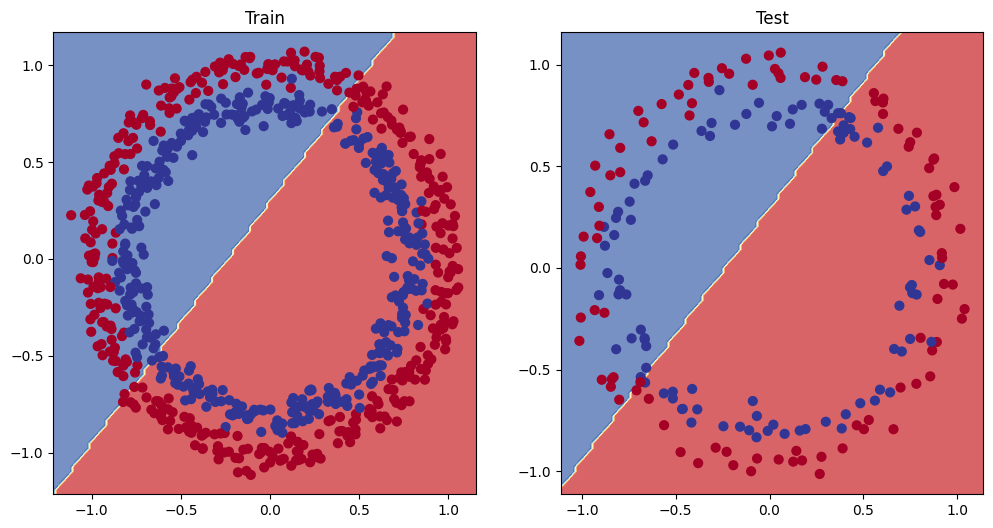

In [31]:
# Plot decision boundary of the model

plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

## Improve a model, we used only Linear layers to figure out a non linear decision boundary....

* Add more layers?
* Add more hidden units? from 5 hidden to 10?
* Give more epochs!
* Change activation function
* Change the lr
* Chagne the loss function or optimizer?



In [32]:
# Improve model by adding more hidden units 5->10
# Increase the numebr of layers 2->6
# increase numebr of epohcs 100->epochs
class CircleModelV2(nn.Module):
  def __init__(self, in_features: int):
    super().__init__()
    layers = []
    layers.append(nn.Linear(in_features=in_features, out_features=10))
    layers.append(nn.Linear(in_features=10, out_features=20))
    layers.append(nn.Linear(in_features=20, out_features=1))
    self.sequential = nn.Sequential(*layers)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.sequential(x)

model_1 = CircleModelV2(in_features=X_train.shape[1]).to(device)
model_1

CircleModelV2(
  (sequential): Sequential(
    (0): Linear(in_features=2, out_features=10, bias=True)
    (1): Linear(in_features=10, out_features=20, bias=True)
    (2): Linear(in_features=20, out_features=1, bias=True)
  )
)

In [33]:
# Create a loss function
loss_fn = nn.BCEWithLogitsLoss()

# Create an optimzer
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.02)

In [34]:
# Write a training and evaluation loop
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Train longer epochs = 10000

epochs = 1000

# Put data on the target device

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):

  ### Training
  model_1.train()

  y_logits = model_1(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  loss = loss_fn(y_logits, y_train) # we need logits because we use BCEWithLogitsLoss
  train_acc = accuracy_fn(y_true=y_train
                          , y_pred=y_pred)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_1.eval()
  with torch.inference_mode():
    test_logits = model_1(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_true=y_test,
                           y_pred=test_pred)



  # Verbose
  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | 'Test loss :{test_loss:.5f} | Train Accuracy: {train_acc:.2f}% | Test Accuracy {test_acc:.2f}%")



Epoch: 0 | Loss: 0.69456 | 'Test loss :0.69737 | Train Accuracy: 51.38% | Test Accuracy 50.00%
Epoch: 100 | Loss: 0.69342 | 'Test loss :0.69626 | Train Accuracy: 50.50% | Test Accuracy 47.00%
Epoch: 200 | Loss: 0.69319 | 'Test loss :0.69588 | Train Accuracy: 50.62% | Test Accuracy 47.00%
Epoch: 300 | Loss: 0.69309 | 'Test loss :0.69562 | Train Accuracy: 51.00% | Test Accuracy 46.50%
Epoch: 400 | Loss: 0.69304 | 'Test loss :0.69542 | Train Accuracy: 50.38% | Test Accuracy 46.00%
Epoch: 500 | Loss: 0.69301 | 'Test loss :0.69526 | Train Accuracy: 51.25% | Test Accuracy 47.50%
Epoch: 600 | Loss: 0.69300 | 'Test loss :0.69514 | Train Accuracy: 51.25% | Test Accuracy 46.50%
Epoch: 700 | Loss: 0.69299 | 'Test loss :0.69504 | Train Accuracy: 51.38% | Test Accuracy 47.00%
Epoch: 800 | Loss: 0.69299 | 'Test loss :0.69496 | Train Accuracy: 50.88% | Test Accuracy 47.00%
Epoch: 900 | Loss: 0.69299 | 'Test loss :0.69490 | Train Accuracy: 51.12% | Test Accuracy 46.50%


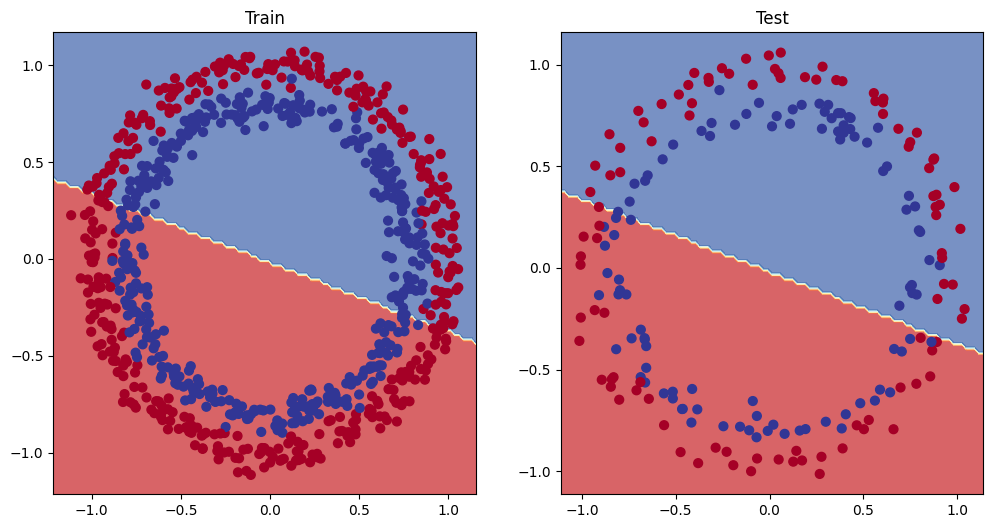

In [35]:
# Plot decision boundary of the model

plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

### Prepare some data to see if the model can fit a strait line!!

In [36]:
weight = 0.8
bias = 0.2

start = 0
end = 10
step = 0.01

X_regression = torch.arange(start=start, end=end, step=0.1).unsqueeze(dim=1)
y_regression = weight * X_regression + bias
X_regression.shape, y_regression.shape

(torch.Size([100, 1]), torch.Size([100, 1]))

In [37]:
# Create train and test splits

train_split = int(0.8 * len(X_regression))
X_train_regression, y_train_regression = X_regression[:train_split], y_regression[:train_split]
X_test_regression, y_test_regression = X_regression[train_split:], y_regression[train_split:]

X_train_regression.shape, y_train_regression.shape

(torch.Size([80, 1]), torch.Size([80, 1]))

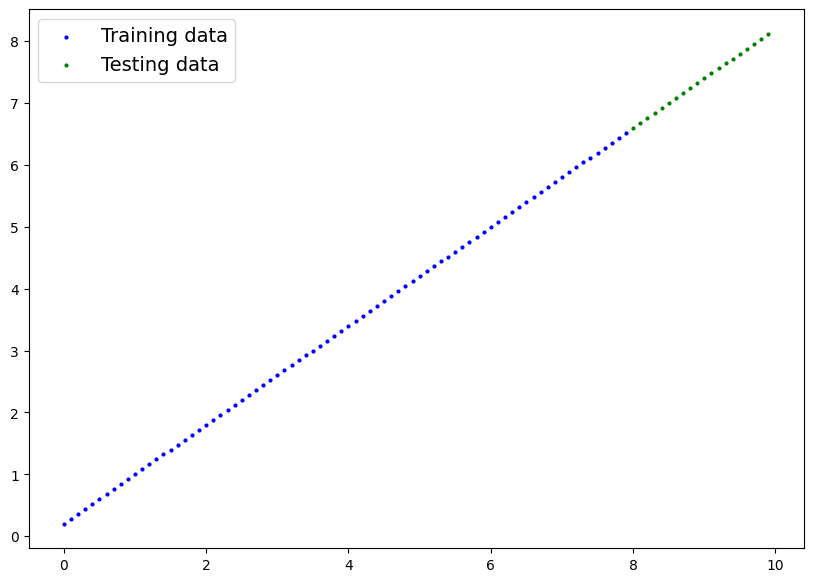

In [38]:
plot_predictions(train_data=X_train_regression,
                train_labels=y_train_regression,
                test_data=X_test_regression,
                test_labels=y_test_regression)

In [39]:
X_train_regression.shape[1], y_train_regression.shape[1]

(1, 1)

In [40]:
model_1

CircleModelV2(
  (sequential): Sequential(
    (0): Linear(in_features=2, out_features=10, bias=True)
    (1): Linear(in_features=10, out_features=20, bias=True)
    (2): Linear(in_features=20, out_features=1, bias=True)
  )
)

### Create new model to fit the linear line!

In [41]:
model_1_reg = CircleModelV2(in_features=X_train_regression.shape[1]).to(device)
model_1_reg

CircleModelV2(
  (sequential): Sequential(
    (0): Linear(in_features=1, out_features=10, bias=True)
    (1): Linear(in_features=10, out_features=20, bias=True)
    (2): Linear(in_features=20, out_features=1, bias=True)
  )
)

In [42]:
# Loss and optimizer

loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model_1_reg.parameters(),
                            lr=0.02)

In [43]:
# Train the model

torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Epochs

epochs = 1000

# Put data to device
X_train_regression, y_train_regression = X_train_regression.to(device), y_train_regression.to(device)
X_test_regression, y_test_regression = X_test_regression.to(device), y_test_regression.to(device)

for epoch in range(epochs):
  model_1_reg.train()

  y_pred = model_1_reg(X_train_regression)
  loss = loss_fn(y_pred, y_train_regression)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_1_reg.eval()
  with torch.inference_mode():
    test_pred = model_1_reg(X_test_regression)
    test_loss = loss_fn(test_pred, y_test_regression)


# Verbose
  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | 'Test loss :{test_loss:.5f}")



Epoch: 0 | Loss: 3.87100 | 'Test loss :5.56177
Epoch: 100 | Loss: 0.10123 | 'Test loss :1.86351
Epoch: 200 | Loss: 0.65831 | 'Test loss :0.08066
Epoch: 300 | Loss: 0.04925 | 'Test loss :1.55664
Epoch: 400 | Loss: 0.29562 | 'Test loss :1.00234
Epoch: 500 | Loss: 0.26344 | 'Test loss :0.95005
Epoch: 600 | Loss: 0.43024 | 'Test loss :0.22084
Epoch: 700 | Loss: 0.04072 | 'Test loss :1.33447
Epoch: 800 | Loss: 0.40445 | 'Test loss :0.17180
Epoch: 900 | Loss: 0.32928 | 'Test loss :0.61892


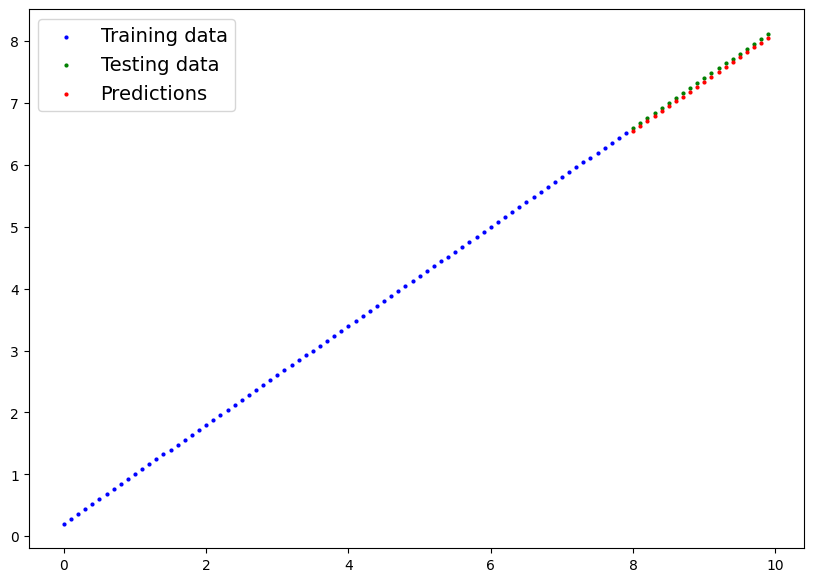

In [44]:
# Make som predictions

model_1_reg.eval()

with torch.inference_mode():
  y_preds = model_1_reg(X_test_regression)

plot_predictions(train_data=X_train_regression.cpu(),
                 train_labels=y_train_regression.cpu(),
                 test_data=X_test_regression.cpu(),
                 test_labels=y_test_regression.cpu(),
                 predictions=y_preds.cpu()
                 )

## The MODEL WORKS FINE FOR A LINEAR REGRESSION OBVIOUSLY BECAUST IT IS A LINEAR MODEL!

We wish to rpeddict a non lienar decision boundary with linear activations that is not going to work therefore we hsould use ome nonlinear activation functions!

## Recreate non-linear data

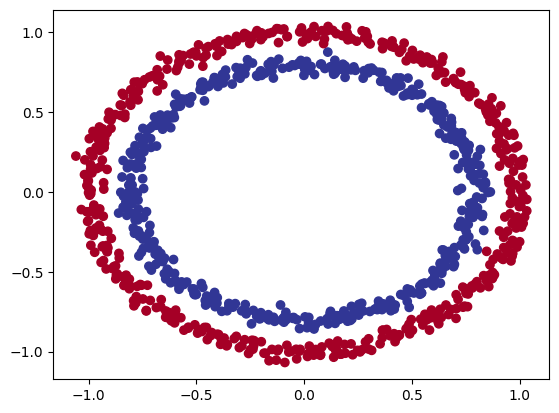

In [45]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000

X, y = make_circles(n_samples,
                    noise=0.03,
                    random_state= 42)
plt.scatter(X[:, 0], X[:,1], c=y, cmap=plt.cm.RdYlBu )

In [46]:
# Convert data to tensor and train test split
import torch
from sklearn.model_selection import train_test_split

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2)

## Building a model with non linearities

In [47]:
from torch import nn

class CircleModelV3(nn.Module):
  def __init__(self, in_feature: int):
    super().__init__()
    layers = []
    layers.append(nn.Linear(in_features=in_feature, out_features=10))
    layers.append(nn.SELU())
    layers.append(nn.Linear(in_features=10, out_features=10))
    layers.append(nn.SELU())
    layers.append(nn.Linear(in_features=10, out_features=5))
    layers.append(nn.SELU())
    layers.append(nn.Linear(in_features=5, out_features=1))
    self.layers = nn.Sequential(*layers)

  def forward(self, x: torch.Tensor):
    return self.layers(x)

model_1_nonlin = CircleModelV3(in_feature=X_train.shape[1]).to(device)
model_1_nonlin

CircleModelV3(
  (layers): Sequential(
    (0): Linear(in_features=2, out_features=10, bias=True)
    (1): SELU()
    (2): Linear(in_features=10, out_features=10, bias=True)
    (3): SELU()
    (4): Linear(in_features=10, out_features=5, bias=True)
    (5): SELU()
    (6): Linear(in_features=5, out_features=1, bias=True)
  )
)

In [48]:
# Setup loss and optimizer AGAIN

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_1_nonlin.parameters(),
                            lr=0.02)

In [49]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test =  X_test.to(device), y_test.to(device)

epochs = 1000

for epoch in range(epochs):

  model_1_nonlin.train()

  y_logits = model_1_nonlin(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  loss = loss_fn(y_logits, y_train)
  train_acc = accuracy_fn(y_true=y_train,
                          y_pred=y_pred)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_1_nonlin.eval()
  with torch.inference_mode():
    test_logits = model_1_nonlin(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_true=y_test,
                           y_pred=test_pred)


  # Verbose
  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | 'Test loss :{test_loss:.5f} | Train Accuracy: {train_acc:.2f}% | Test Accuracy {test_acc:.2f}%")


Epoch: 0 | Loss: 0.70846 | 'Test loss :0.71353 | Train Accuracy: 51.00% | Test Accuracy 46.00%
Epoch: 100 | Loss: 0.00696 | 'Test loss :0.00651 | Train Accuracy: 100.00% | Test Accuracy 100.00%
Epoch: 200 | Loss: 0.00210 | 'Test loss :0.00309 | Train Accuracy: 100.00% | Test Accuracy 100.00%
Epoch: 300 | Loss: 0.00111 | 'Test loss :0.00207 | Train Accuracy: 100.00% | Test Accuracy 100.00%
Epoch: 400 | Loss: 0.00070 | 'Test loss :0.00164 | Train Accuracy: 100.00% | Test Accuracy 100.00%
Epoch: 500 | Loss: 0.00048 | 'Test loss :0.00141 | Train Accuracy: 100.00% | Test Accuracy 100.00%
Epoch: 600 | Loss: 0.00035 | 'Test loss :0.00124 | Train Accuracy: 100.00% | Test Accuracy 100.00%
Epoch: 700 | Loss: 0.00027 | 'Test loss :0.00114 | Train Accuracy: 100.00% | Test Accuracy 100.00%
Epoch: 800 | Loss: 0.00021 | 'Test loss :0.00105 | Train Accuracy: 100.00% | Test Accuracy 100.00%
Epoch: 900 | Loss: 0.00017 | 'Test loss :0.00097 | Train Accuracy: 100.00% | Test Accuracy 100.00%


## Make predictions and evaluate the model

In [50]:
# Make predictions
model_1_nonlin.eval()
with torch.inference_mode():
  y_preds = torch.round(torch.sigmoid(model_1_nonlin(X_test))).squeeze()
y_preds[:10], y_test[:10]

(tensor([0., 1., 0., 1., 0., 1., 0., 0., 0., 1.], device='cuda:0'),
 tensor([0., 1., 0., 1., 0., 1., 0., 0., 0., 1.], device='cuda:0'))

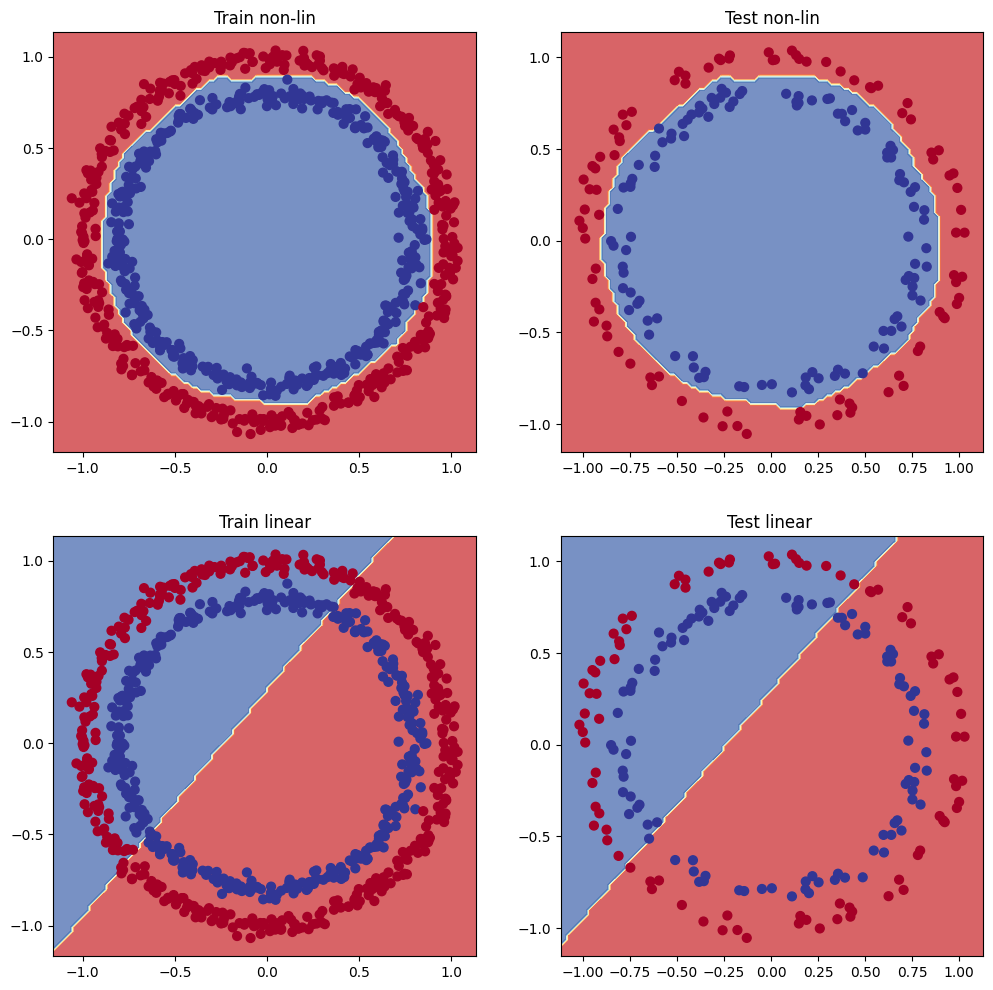

In [51]:
# Plot decision boundary of the model

plt.figure(figsize=(12,12))
plt.subplot(2, 2, 1)
plt.title("Train non-lin")
plot_decision_boundary(model_1_nonlin, X_train, y_train)
plt.subplot(2, 2, 2)
plt.title("Test non-lin")
plot_decision_boundary(model_1_nonlin, X_test, y_test)
plt.subplot(2, 2, 3)
plt.title("Train linear")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(2, 2, 4)
plt.title("Test linear ")
plot_decision_boundary(model_0, X_test, y_test)

## Put everything together into a multi-class classification

###  Creeate the toy mutli-class dataset

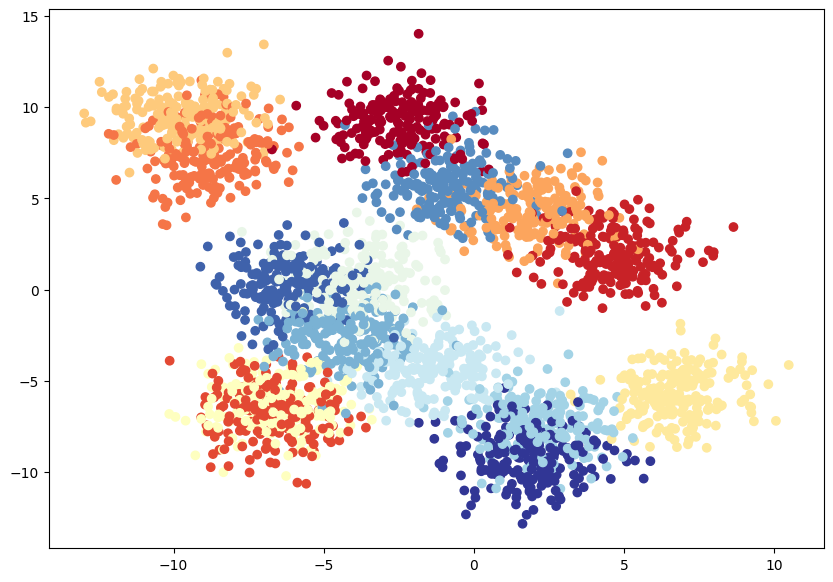

In [115]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Set the hyperparmeters for data creation

NUM_SAMPLES = 3000
NUM_CLASSES = 15
NUM_FEATURES = 2
RANDOM_SEED = 42

# Make data
X_blob, y_blob = make_blobs(n_samples=NUM_SAMPLES,
                            n_features=NUM_FEATURES,
                            centers=NUM_CLASSES,
                            cluster_std=1.3,
                            random_state=RANDOM_SEED)

# Trun data into tensors

X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.long)

# Split into train, test

X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,
                                                                         y_blob,
                                                                         test_size=0.2,
                                                                         random_state=RANDOM_SEED
                                                                         )

# Plot the data
plt.figure(figsize=(10,7))
plt.scatter(X_blob[:, 0], X_blob[:, 1],
            c=y_blob, cmap=plt.cm.RdYlBu)


In [116]:
X_blob_train.shape, y_blob_train.shape

(torch.Size([2400, 2]), torch.Size([2400]))

In [117]:
X_blob_train[:5], y_blob_train[:5]

(tensor([[ 9.2002, -5.7484],
         [-0.2457, -5.2521],
         [ 9.0811, -5.2467],
         [-7.6087,  1.5229],
         [-5.9316, -1.7608]]),
 tensor([ 6,  9,  6, 13, 11]))

In [118]:
torch.unique(y_blob_train)

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

## Build multi-class classification in PyTorch

In [119]:
# Device angostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [120]:
class BlobModel(nn.Module):
  def __init__(self, in_features: int, out_features: int, hidden_units: int= 8):
    super().__init__()
    layers = []
    layers.append(nn.Linear(in_features=in_features, out_features=hidden_units))
    layers.append(nn.SELU())
    layers.append(nn.Linear(in_features=hidden_units, out_features=hidden_units))
    layers.append(nn.SELU())
    layers.append(nn.Linear(in_features=hidden_units, out_features=hidden_units))
    layers.append(nn.SELU())
    layers.append(nn.Linear(in_features=hidden_units, out_features=out_features))

    self.layers = nn.Sequential(*layers)

  def forward(self, x: torch.Tensor):
    return self.layers(x)

blob_model = BlobModel(in_features=X_blob_train.shape[1],
                       out_features=len(torch.unique(y_blob_train)),
                       ).to(device)
blob_model

BlobModel(
  (layers): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): SELU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): SELU()
    (4): Linear(in_features=8, out_features=8, bias=True)
    (5): SELU()
    (6): Linear(in_features=8, out_features=15, bias=True)
  )
)

### Loss functi onand optimizer for multi-class classification

In [121]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(blob_model.parameters(),
                             lr=0.02)

### Getting predcti onprobabilities for a mutli-class model
logits -> pred probns -> pred labels

In [122]:
# Lets get the raw outputs (logits)
blob_model.eval()
with torch.inference_mode():
  y_logits = blob_model(X_blob_test.to(device))
y_logits[:10]

tensor([[ 0.1953, -0.0248,  0.2897,  0.1842, -0.4778, -0.0463,  0.2961,  0.1219,
          0.1985,  0.1549, -0.2590, -0.1998, -0.0534,  0.1739,  0.0405],
        [ 0.2076, -0.0225,  0.3016,  0.1876, -0.4666, -0.0543,  0.3026,  0.1208,
          0.2272,  0.1751, -0.2376, -0.1911, -0.0362,  0.1891,  0.0477],
        [ 0.3738, -0.1423,  0.3053,  0.1474, -0.3074, -0.0530,  0.2456,  0.1799,
          0.4262,  0.4038, -0.1605,  0.0336,  0.0538,  0.1363,  0.1672],
        [ 0.2933, -0.1361,  0.1679,  0.0731, -0.5037, -0.1659,  0.2543, -0.0726,
          0.0115,  0.1467, -0.3864, -0.0937, -0.1869, -0.0186,  0.0401],
        [ 0.3548, -0.2142,  0.2483,  0.1050, -0.3700, -0.0630,  0.2437,  0.1002,
          0.2853,  0.2881, -0.3415,  0.0221, -0.0930,  0.0390,  0.1145],
        [ 0.5598, -0.1364, -0.4747, -0.4007, -0.6067, -0.7505, -0.0026, -0.7473,
         -1.0549,  0.1963, -0.0874, -0.1284, -0.2727, -0.7350,  0.1404],
        [ 0.3799, -0.3237,  0.2182,  0.0651, -0.3613, -0.0152,  0.2399,  0.1

In [123]:
# Convert logits into pred probabilieits
y_pred_probs = torch.softmax(y_logits, dim=1)
print(y_logits[:5])
print(y_pred_probs[:5])

tensor([[ 0.1953, -0.0248,  0.2897,  0.1842, -0.4778, -0.0463,  0.2961,  0.1219,
          0.1985,  0.1549, -0.2590, -0.1998, -0.0534,  0.1739,  0.0405],
        [ 0.2076, -0.0225,  0.3016,  0.1876, -0.4666, -0.0543,  0.3026,  0.1208,
          0.2272,  0.1751, -0.2376, -0.1911, -0.0362,  0.1891,  0.0477],
        [ 0.3738, -0.1423,  0.3053,  0.1474, -0.3074, -0.0530,  0.2456,  0.1799,
          0.4262,  0.4038, -0.1605,  0.0336,  0.0538,  0.1363,  0.1672],
        [ 0.2933, -0.1361,  0.1679,  0.0731, -0.5037, -0.1659,  0.2543, -0.0726,
          0.0115,  0.1467, -0.3864, -0.0937, -0.1869, -0.0186,  0.0401],
        [ 0.3548, -0.2142,  0.2483,  0.1050, -0.3700, -0.0630,  0.2437,  0.1002,
          0.2853,  0.2881, -0.3415,  0.0221, -0.0930,  0.0390,  0.1145]],
       device='cuda:0')
tensor([[0.0763, 0.0612, 0.0838, 0.0754, 0.0389, 0.0599, 0.0844, 0.0709, 0.0765,
         0.0733, 0.0484, 0.0514, 0.0595, 0.0747, 0.0653],
        [0.0764, 0.0607, 0.0839, 0.0749, 0.0389, 0.0588, 0.0840, 0

In [124]:
torch.sum(y_pred_probs[0])

tensor(1.0000, device='cuda:0')

In [125]:
torch.max(y_pred_probs[0]), torch.argmax(y_pred_probs[0])

(tensor(0.0844, device='cuda:0'), tensor(6, device='cuda:0'))

In [126]:
# Conver model prediction probabilities into labels!
y_preds = torch.argmax(y_pred_probs, dim=1)
y_preds[:5]

tensor([6, 6, 8, 0, 0], device='cuda:0')

In [127]:
## Training loop and testing loop

In [128]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000

# Data into device!

X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

for epoch in range(epochs):
  blob_model.train()

  logits = blob_model(X_blob_train)
  y_pred = torch.softmax(logits, dim=1).argmax(dim=1)

  loss = loss_fn(logits, y_blob_train)
  train_acc = accuracy_fn(y_true=y_blob_train,
                          y_pred=y_pred)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  blob_model.eval()
  with torch.inference_mode():
    test_logits = blob_model(X_blob_test)
    test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
    test_loss = loss_fn(test_logits, y_blob_test)
    test_acc = accuracy_fn(y_true=y_blob_test,
                           y_pred=test_pred)


  # Verbose
  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | 'Test loss :{test_loss:.5f} | Train Accuracy: {train_acc:.2f}% | Test Accuracy {test_acc:.2f}%")

Epoch: 0 | Loss: 2.64183 | 'Test loss :2.45843 | Train Accuracy: 10.62% | Test Accuracy 27.33%
Epoch: 100 | Loss: 0.49490 | 'Test loss :0.46397 | Train Accuracy: 77.83% | Test Accuracy 78.00%
Epoch: 200 | Loss: 0.48413 | 'Test loss :0.46470 | Train Accuracy: 77.79% | Test Accuracy 78.33%
Epoch: 300 | Loss: 0.48055 | 'Test loss :0.46584 | Train Accuracy: 78.17% | Test Accuracy 78.33%
Epoch: 400 | Loss: 0.47799 | 'Test loss :0.46983 | Train Accuracy: 77.75% | Test Accuracy 77.83%
Epoch: 500 | Loss: 0.47550 | 'Test loss :0.46957 | Train Accuracy: 78.12% | Test Accuracy 78.33%
Epoch: 600 | Loss: 0.47430 | 'Test loss :0.47084 | Train Accuracy: 78.46% | Test Accuracy 77.67%
Epoch: 700 | Loss: 0.47171 | 'Test loss :0.47495 | Train Accuracy: 78.42% | Test Accuracy 77.17%
Epoch: 800 | Loss: 0.46977 | 'Test loss :0.47716 | Train Accuracy: 78.50% | Test Accuracy 77.67%
Epoch: 900 | Loss: 0.46948 | 'Test loss :0.48013 | Train Accuracy: 78.62% | Test Accuracy 77.00%


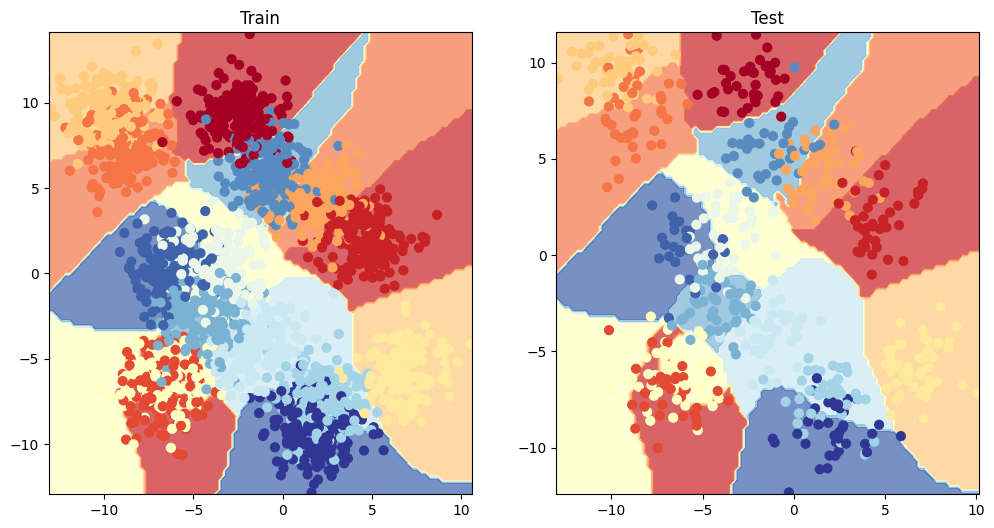

In [129]:
# Plot decision boundary of the model

plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(blob_model, X_blob_train, y_blob_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(blob_model, X_blob_test, y_blob_test)
